c:\Users\Daniel\interview\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


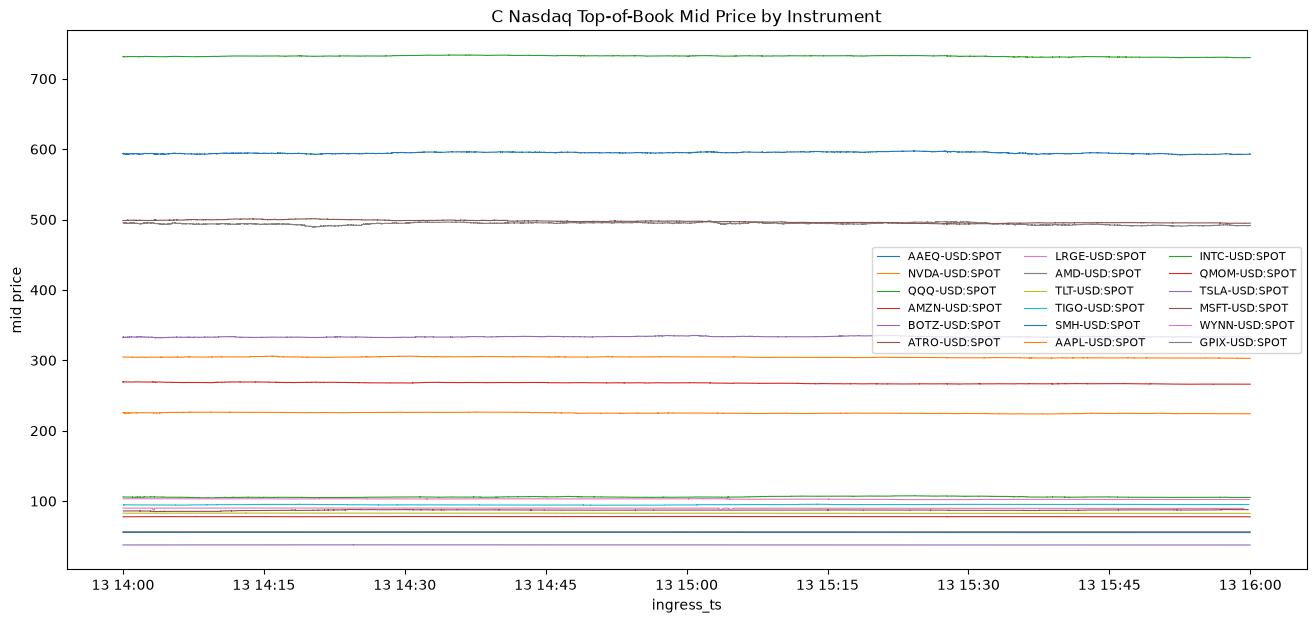

In [1]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet("../parquets/C_nasdaq_top_of_book_20_symbols.parquet")

df_plot = (
    df.sort(["instrument", "ingress_ts"])
    .with_columns(mid=(pl.col("bid_price") + pl.col("ask_price")) / 2)
    .select("instrument", "ingress_ts", "mid")
    .drop_nulls()
)

plt.figure(figsize=(16, 7))

for instrument in df_plot["instrument"].unique().to_list():
    x = df_plot.filter(pl.col("instrument") == instrument)
    plt.plot(x["ingress_ts"], x["mid"], linewidth=0.8, label=instrument)

plt.title("C Nasdaq Top-of-Book Mid Price by Instrument")
plt.xlabel("ingress_ts")
plt.ylabel("mid price")
plt.legend(ncol=3, fontsize=8)
plt.show()

In [2]:
df.null_count()

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [8]:
df.sort(["instrument", "seq_id"]).group_by("instrument").agg(
    pl.col("publish_ts").is_sorted().alias("publish_monotonic"),
    pl.col("transaction_ts").is_sorted().alias("transaction_monotonic"),
    pl.col("ingress_ts").is_sorted().alias("ingress_monotonic"),
).select(
    pl.col("publish_monotonic").value_counts().alias("publish_counts"),
    pl.col("transaction_monotonic").value_counts().alias("transaction_counts"),
    pl.col("ingress_monotonic").value_counts().alias("ingress_counts"),
)

publish_counts,transaction_counts,ingress_counts
struct[2],struct[2],struct[2]
"{true,18}","{false,18}","{false,18}"


In [9]:
df.with_columns(
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
).select(
    pl.col("crossed_book").sum().alias("crossed_book_count"),
    pl.col("locked_book").sum().alias("locked_book_count"),
)

crossed_book_count,locked_book_count
u32,u32
1030,26814


In [10]:
df.with_columns(
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
).group_by("instrument").agg(
    pl.len().alias("rows"),
    pl.col("crossed_book").sum().alias("crossed_book"),
    pl.col("locked_book").sum().alias("locked_book"),
).with_columns(
    crossed_pct=pl.col("crossed_book") / pl.col("rows") * 100,
    locked_pct=pl.col("locked_book") / pl.col("rows") * 100,
).sort("crossed_book", descending=True)

instrument,rows,crossed_book,locked_book,crossed_pct,locked_pct
str,u32,u32,u32,f64,f64
"""AAPL-USD:SPOT""",326952,233,1359,0.071264,0.415657
"""QQQ-USD:SPOT""",1010088,221,5311,0.021879,0.525796
"""INTC-USD:SPOT""",720879,194,6913,0.026912,0.958968
"""TSLA-USD:SPOT""",168559,158,462,0.093736,0.274088
"""NVDA-USD:SPOT""",618876,96,4226,0.015512,0.682851
…,…,…,…,…,…
"""TIGO-USD:SPOT""",42581,0,0,0.0,0.0
"""AAEQ-USD:SPOT""",3593,0,0,0.0,0.0
"""WYNN-USD:SPOT""",26827,0,2,0.0,0.007455


In [11]:
df = df.with_columns(
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

In [12]:
df.filter(
    (pl.col("bid_price") <= 0)
    | (pl.col("ask_price") <= 0)
    | (pl.col("bid_qty") <= 0)
    | (pl.col("ask_qty") <= 0)
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,crossed_book,locked_book
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool


In [13]:
df = df.with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2,
    spread=pl.col("ask_price") - pl.col("bid_price"),
)
df = df.with_columns(spread_pct=pl.col("spread") / pl.col("mid") * 100)

df.group_by("instrument").agg(
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

instrument,p99_spread_pct,max_spread_pct
str,f64,f64
"""SMH-USD:SPOT""",0.053671,0.141424
"""BOTZ-USD:SPOT""",0.05305,0.053093
"""AMZN-USD:SPOT""",0.029861,0.075047
"""WYNN-USD:SPOT""",0.223638,0.389143
"""QQQ-USD:SPOT""",0.005478,0.023204
…,…,…
"""MSFT-USD:SPOT""",0.05,0.093168
"""AAEQ-USD:SPOT""",0.090098,0.469484
"""GPIX-USD:SPOT""",0.035261,0.035379


In [16]:
df = df.with_columns(
    spread_outlier=pl.col("spread_pct") > pl.col("spread_pct").quantile(0.99).over("instrument")
)
df.group_by("instrument").agg(
    pl.col("spread_outlier").sum().alias("spread_outlier_count")
).sort("spread_outlier_count", descending=True)

instrument,spread_outlier_count
str,u32
"""QQQ-USD:SPOT""",9954
"""INTC-USD:SPOT""",7207
"""NVDA-USD:SPOT""",5968
"""AAPL-USD:SPOT""",3251
"""AMZN-USD:SPOT""",2743
…,…
"""LRGE-USD:SPOT""",83
"""QMOM-USD:SPOT""",68
"""BOTZ-USD:SPOT""",37


In [19]:
df.filter((pl.col("bid_qty") % 10) != 0)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,crossed_book,locked_book,mid,spread,spread_pct,spread_outlier
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,f64,f64,f64,bool
